In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
files = []
for file in os.listdir():
    if file[-3:] == 'csv':
        print(file)
        files.append(file)

3610023001_databaseLoadingData.csv
3610023201_databaseLoadingData.csv
3610023501_databaseLoadingData.csv
3610023401_databaseLoadingData.csv


In [8]:
df.columns

Index(['REF_DATE', 'GEO', 'DGUID', 'Prices', 'Seasonal adjustment',
       'Indicators', 'Products', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID',
       'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED',
       'DECIMALS'],
      dtype='object')

In [216]:
df = pd.read_csv("3610023001_databaseLoadingData.csv").drop(['DGUID', 'UOM_ID', 'VECTOR',
                                                             'SCALAR_ID', 'COORDINATE', 
                                                             'VALUE', 'STATUS', 'SYMBOL',
                                                             'TERMINATED', 'DECIMALS'], axis=1)
df.head()
#for col in df.columns:
#    print(col)
#    print(df[col].unique())
#    print("")

,REF_DATE,GEO,Prices,Seasonal adjustment,Indicators,Products,UOM,SCALAR_FACTOR
0,2010-01,Canada,2017 constant prices,Seasonally adjusted at quarterly rates,Tourism demand,Tourism expenditures,Dollars,millions
1,2010-04,Canada,2017 constant prices,Seasonally adjusted at quarterly rates,Tourism demand,Tourism expenditures,Dollars,millions
2,2010-07,Canada,2017 constant prices,Seasonally adjusted at quarterly rates,Tourism demand,Tourism expenditures,Dollars,millions
3,2010-10,Canada,2017 constant prices,Seasonally adjusted at quarterly rates,Tourism demand,Tourism expenditures,Dollars,millions
4,2011-01,Canada,2017 constant prices,Seasonally adjusted at quarterly rates,Tourism demand,Tourism expenditures,Dollars,millions


In [215]:
#for file in files:
#    print(file)
#    df = pd.read_csv(file).drop(['DGUID', 'UOM_ID', 'VECTOR',
#                                 'SCALAR_ID', 'COORDINATE', 
#                                 'STATUS', 'SYMBOL',
#                                 'TERMINATED', 'DECIMALS'], axis=1)
#    for col in df.columns:
#        print(col)
#        print(df[col].unique())
#        print("")
#    print("")
#    print("")
#    print("")

In [15]:
tourism_demand = pd.read_csv('3610023001_databaseLoadingData.csv')
tourism_jobs = pd.read_csv('3610023201_databaseLoadingData.csv')
tourism_gdp_share = pd.read_csv('3610023501_databaseLoadingData.csv')
tourism_industry_expenditure = pd.read_csv('3610023401_databaseLoadingData.csv')

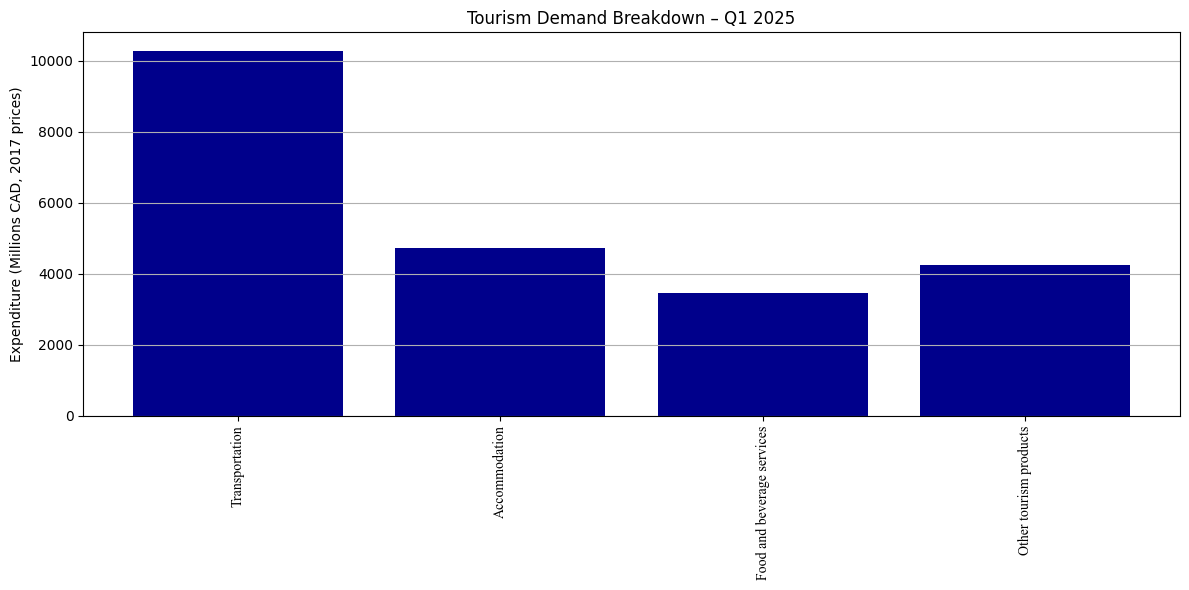

In [71]:
q1_2025_demand = tourism_demand[
    (tourism_demand["REF_DATE"] == "2025-01")
    & (tourism_demand["Indicators"] == "Tourism demand")
    & (tourism_demand["Products"] != 'Tourism expenditures')
]

plt.figure(figsize=(12, 6))
plt.bar(q1_2025_demand["Products"], q1_2025_demand["VALUE"], color = 'darkblue')
plt.title("Tourism Demand Breakdown – Q1 2025")
plt.ylabel("Expenditure (Millions CAD, 2017 prices)")
plt.xticks(rotation=90, fontname= 'Times New Roman')
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()

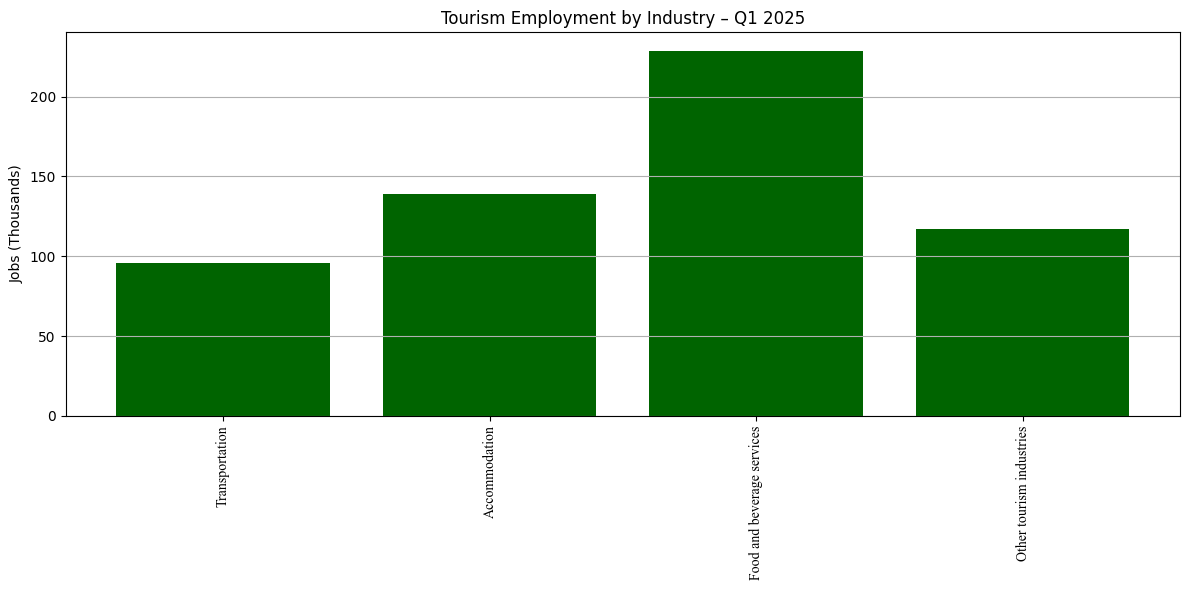

In [70]:
q1_2025_jobs = tourism_jobs[
    (tourism_jobs["REF_DATE"] == "2025-01")
        & (tourism_jobs["Industries"] != 'Tourism activities')

]

plt.figure(figsize=(12, 6))
plt.bar(q1_2025_jobs["Industries"], q1_2025_jobs["VALUE"], color ='darkgreen')
plt.title("Tourism Employment by Industry – Q1 2025")
plt.ylabel("Jobs (Thousands)")
plt.xticks(rotation=90, fontname= 'Times New Roman')
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()

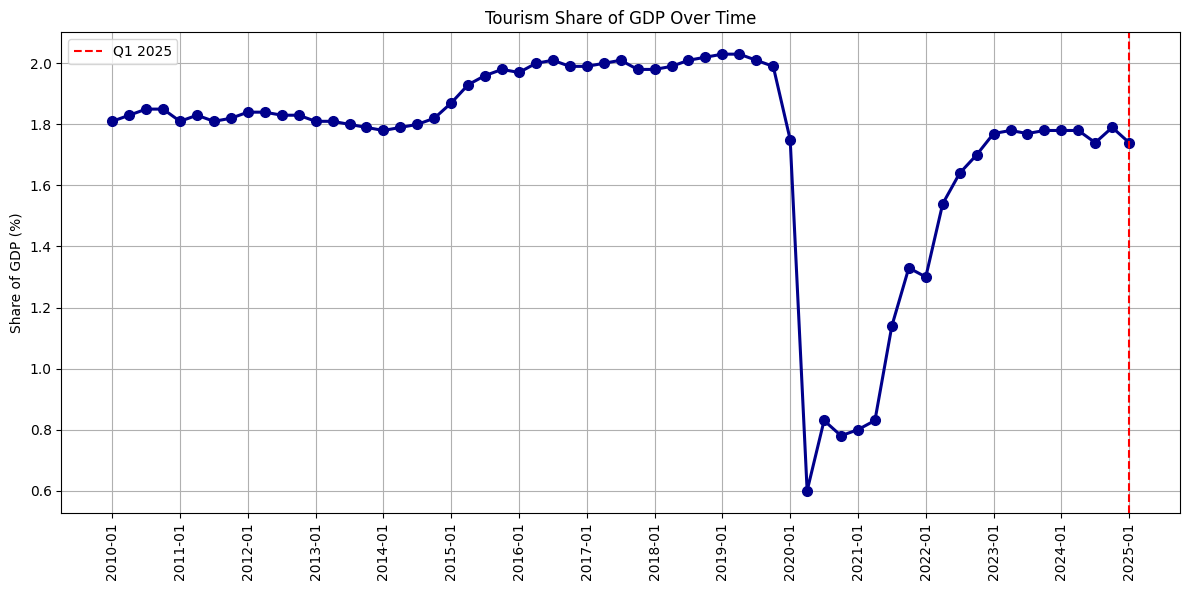

In [69]:
plt.figure(figsize=(12, 6))
plt.plot(tourism_gdp_share["REF_DATE"], tourism_gdp_share["VALUE"], marker='o', color = 'darkblue',
        lw = 2.2, markersize=7)
plt.title("Tourism Share of GDP Over Time")
plt.ylabel("Share of GDP (%)")
plt.xticks(np.arange(0,61, 4), list(tourism_gdp_share.REF_DATE)[::4], rotation=90)
plt.axvline("2025-01", color='red', linestyle='--', label="Q1 2025")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

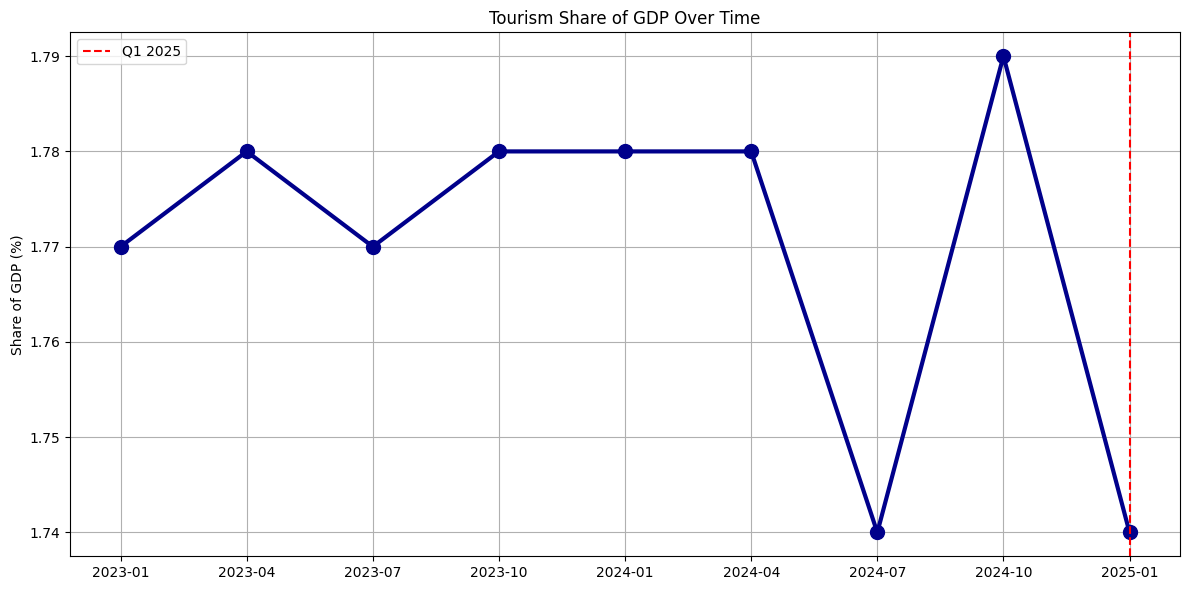

In [64]:
plt.figure(figsize=(12, 6))
tourism_gdp_share_2 = tourism_gdp_share[
    (tourism_gdp_share["REF_DATE"] >= "2023-01")
]
plt.plot(tourism_gdp_share_2["REF_DATE"], tourism_gdp_share_2["VALUE"], marker='o', color = 'darkblue', 
         lw = 3, markersize=10)
plt.title("Tourism Share of GDP Over Time")
plt.ylabel("Share of GDP (%)")
#plt.xticks(np.arange(0,61, 4), list(tourism_gdp_share.REF_DATE)[::4], rotation=90)
plt.axvline("2025-01", color='red', linestyle='--', label="Q1 2025")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

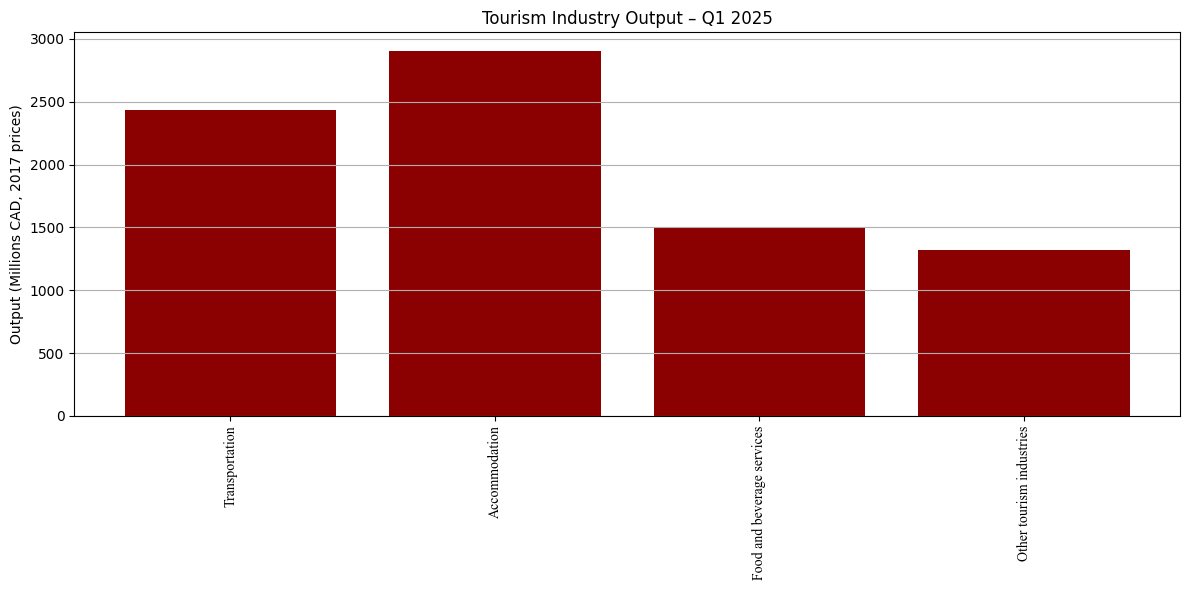

In [59]:
q1_2025_output = tourism_industry_expenditure[
    (tourism_industry_expenditure["REF_DATE"] == "2025-01")
     & (tourism_industry_expenditure["Industries"] != 'Tourism activities')

]

plt.figure(figsize=(12, 6))
plt.bar(q1_2025_output["Industries"], q1_2025_output["VALUE"], color = 'darkred')
plt.title("Tourism Industry Output – Q1 2025")
plt.ylabel("Output (Millions CAD, 2017 prices)")
plt.xticks(rotation=90, fontname= 'Times New Roman')
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()

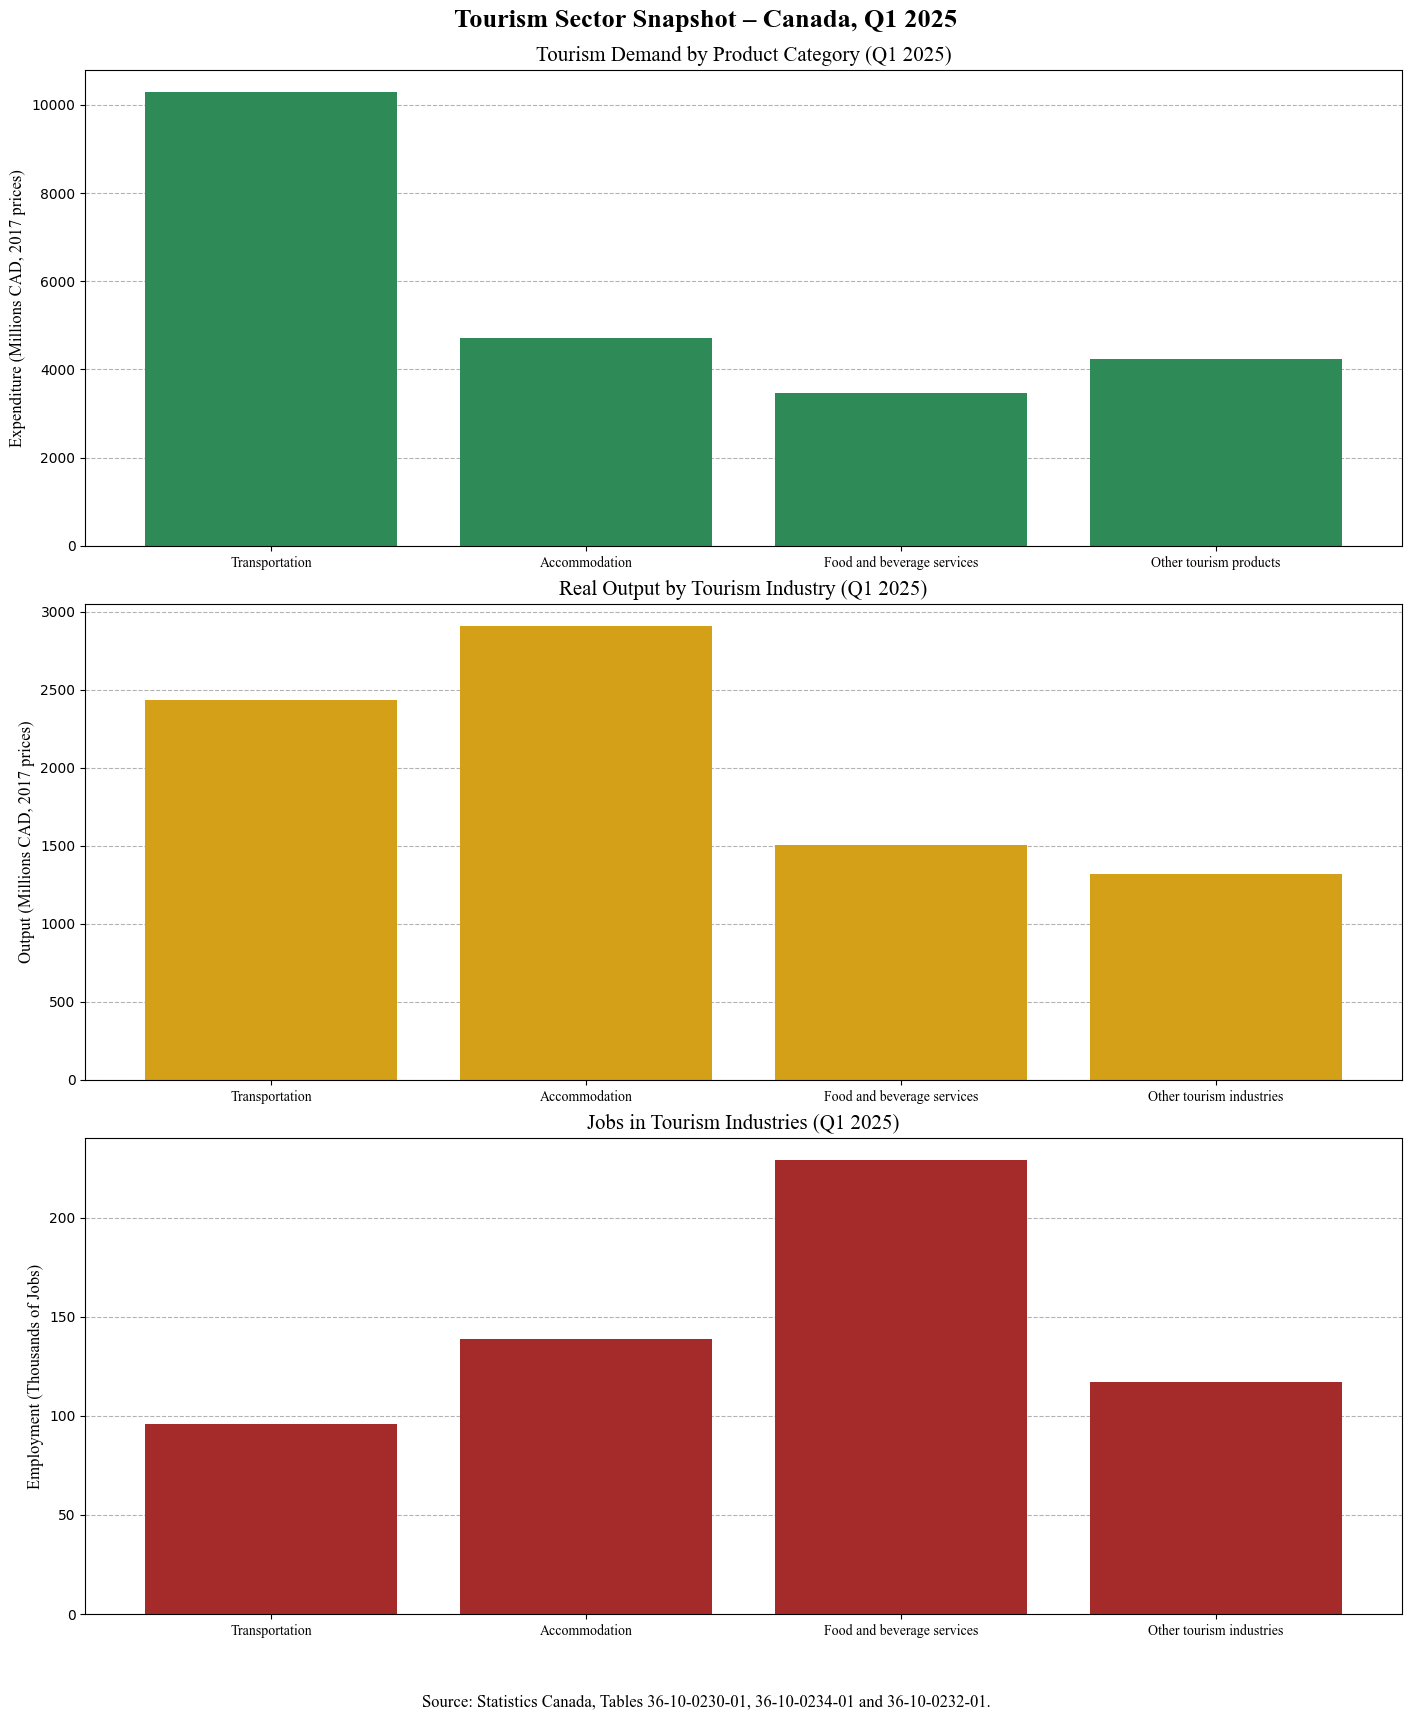

In [210]:
fig, axs = plt.subplots(3, 1, figsize=(14, 16), constrained_layout=True)

axs[0].bar(q1_2025_demand["Products"], q1_2025_demand["VALUE"], color='#2e8b57', zorder=2)
axs[0].set_title("Tourism Demand by Product Category (Q1 2025)", fontname='Times New Roman', fontsize=15)
axs[0].set_ylabel("Expenditure (Millions CAD, 2017 prices)", fontname='Times New Roman', fontsize=12)
axs[0].tick_params(axis='x', rotation=0)
for label in axs[0].get_xticklabels():
    label.set_fontname('Times New Roman')
    label.set_fontsize(10)
axs[0].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=1, c='k')


axs[1].bar(q1_2025_output["Industries"], q1_2025_output["VALUE"], color='#d4a017', zorder=2)
axs[1].set_title("Real Output by Tourism Industry (Q1 2025)", fontname='Times New Roman', fontsize=15)
axs[1].set_ylabel("Output (Millions CAD, 2017 prices)", fontname='Times New Roman', fontsize=12)
axs[1].tick_params(axis='x', rotation=0)
for label in axs[1].get_xticklabels():
    label.set_fontname('Times New Roman')
    label.set_fontsize(10)
axs[1].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=1, c='k')


axs[2].bar(q1_2025_jobs["Industries"], q1_2025_jobs["VALUE"], color='#a52a2a', zorder=2)
axs[2].set_title("Jobs in Tourism Industries (Q1 2025)", fontname='Times New Roman', fontsize=15)
axs[2].set_ylabel("Employment (Thousands of Jobs)", fontname='Times New Roman', fontsize=12)
axs[2].tick_params(axis='x', rotation=0)
for label in axs[2].get_xticklabels():
    label.set_fontname('Times New Roman')
    label.set_fontsize(10)
axs[2].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=1, c='k')


plt.suptitle("Tourism Sector Snapshot – Canada, Q1 2025",fontweight='bold', y=1.02,
            fontname='Times New Roman', fontsize=19)

plt.figtext(0.5, -0.04,
            'Source: Statistics Canada, Tables 36-10-0230-01, 36-10-0234-01 and 36-10-0232-01.',
            wrap=True, horizontalalignment='center', fontsize=12, fontname='Times New Roman', weight='medium')

#plt.savefig('tourism_snapshot_Q1_2025.png', dpi=500, bbox_inches='tight')


plt.show()

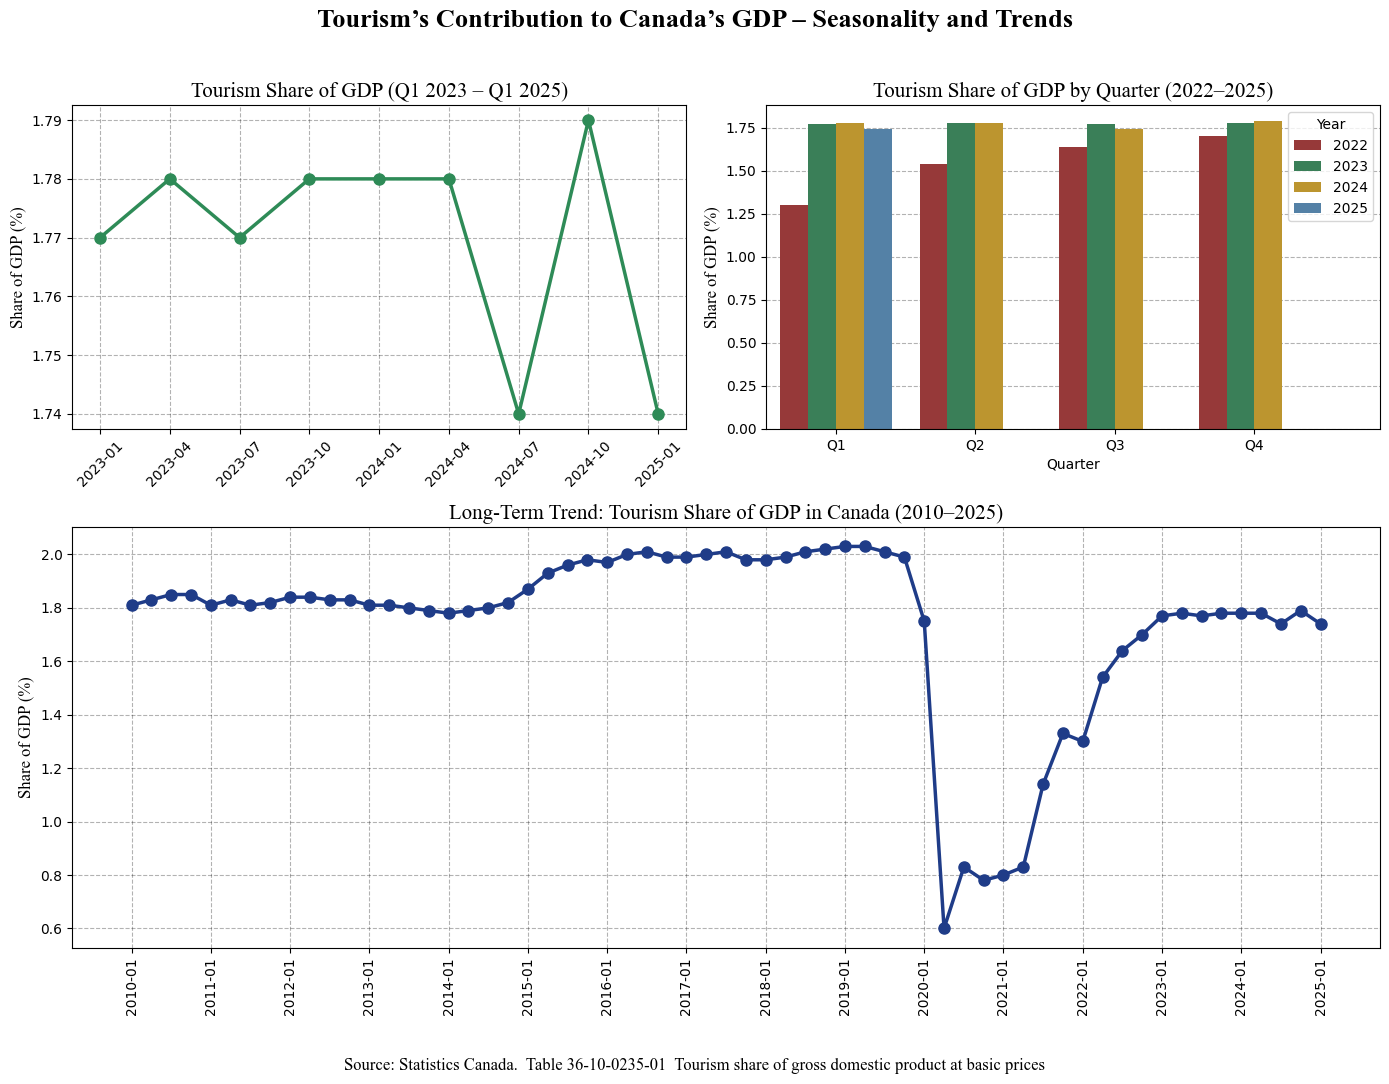

In [204]:
gdp_share_recent = tourism_gdp_share[tourism_gdp_share["REF_DATE"] >= "2023-01"].copy()
gdp_share_quarterly = tourism_gdp_share[tourism_gdp_share["REF_DATE"] >= "2022-01"].copy()
gdp_share_long = tourism_gdp_share.copy()


gdp_share_quarterly["Year"] = gdp_share_quarterly["REF_DATE"].str[:4]
gdp_share_quarterly["Quarter"] = gdp_share_quarterly["REF_DATE"].str[-2:].replace({
    "01": "Q1", "04": "Q2", "07": "Q3", "10": "Q4"
})
gdp_share_quarterly["Quarter"] = pd.Categorical(
    gdp_share_quarterly["Quarter"], categories=["Q1", "Q2", "Q3", "Q4"], ordered=True
)
gdp_share_quarterly = gdp_share_quarterly.sort_values(["Year", "Quarter"])


fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.3])
ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1]) 
ax3 = fig.add_subplot(gs[1, :]) 


ax1.plot(gdp_share_recent["REF_DATE"], gdp_share_recent["VALUE"], marker='o', color='#2e8b57',
        lw = 2.5, markersize=8)
ax1.set_title("Tourism Share of GDP (Q1 2023 – Q1 2025)",
             fontname='Times New Roman', fontsize=15)
ax1.set_ylabel("Share of GDP (%)", fontname='Times New Roman', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.3, c='k')


sns.barplot(
    data=gdp_share_quarterly,
    x="Quarter", y="VALUE", hue="Year",
    ax=ax2,
    palette={"2022": "#a52a2a", "2023": "#2e8b57", "2024": "#d4a017", "2025": "#4682b4"},
        zorder=2

)
ax2.set_title("Tourism Share of GDP by Quarter (2022–2025)", 
             fontname='Times New Roman', fontsize=15)
ax2.set_ylabel("Share of GDP (%)", fontname='Times New Roman', fontsize=12)
ax2.grid(True, axis='y', linestyle='--', alpha=0.3, c='k', zorder=1, )


ax2.set_xlim(-0.5, 3.9)


ax2.legend(title="Year", loc='upper right', bbox_to_anchor=(1, 1), frameon=True)

#ax2.yaxis.tick_right()
#ax2.yaxis.set_label_position("right")


ax3.plot(gdp_share_long["REF_DATE"], gdp_share_long["VALUE"], marker='o', color='#1f3c88', 
         lw = 2.5, markersize=8)
ax3.set_title("Long-Term Trend: Tourism Share of GDP in Canada (2010–2025)", 
              fontname='Times New Roman', fontsize=15)
ax3.set_ylabel("Share of GDP (%)", fontname='Times New Roman', fontsize=12)

tick_locs = np.arange(0, len(gdp_share_long), 4)
tick_labels = [gdp_share_long["REF_DATE"].iloc[i] for i in tick_locs]
ax3.set_xticks(tick_locs)
ax3.set_xticklabels(tick_labels, rotation=90)

ax3.grid(True, linestyle='--', alpha=0.3, c='k')


plt.suptitle("Tourism’s Contribution to Canada’s GDP – Seasonality and Trends", 
             fontsize=19, fontweight='bold', y=1.02, fontname='Times New Roman')

plt.figtext(0.5, -0.04,
            'Source: Statistics Canada.  Table 36-10-0235-01  Tourism share of gross domestic product at basic prices',
            wrap=True, horizontalalignment='center', fontsize=12, fontname='Times New Roman', weight='medium')


plt.tight_layout()
#plt.savefig('tourism_gdp_share_trends_2023_2025.png', dpi=500, bbox_inches='tight')

plt.show()


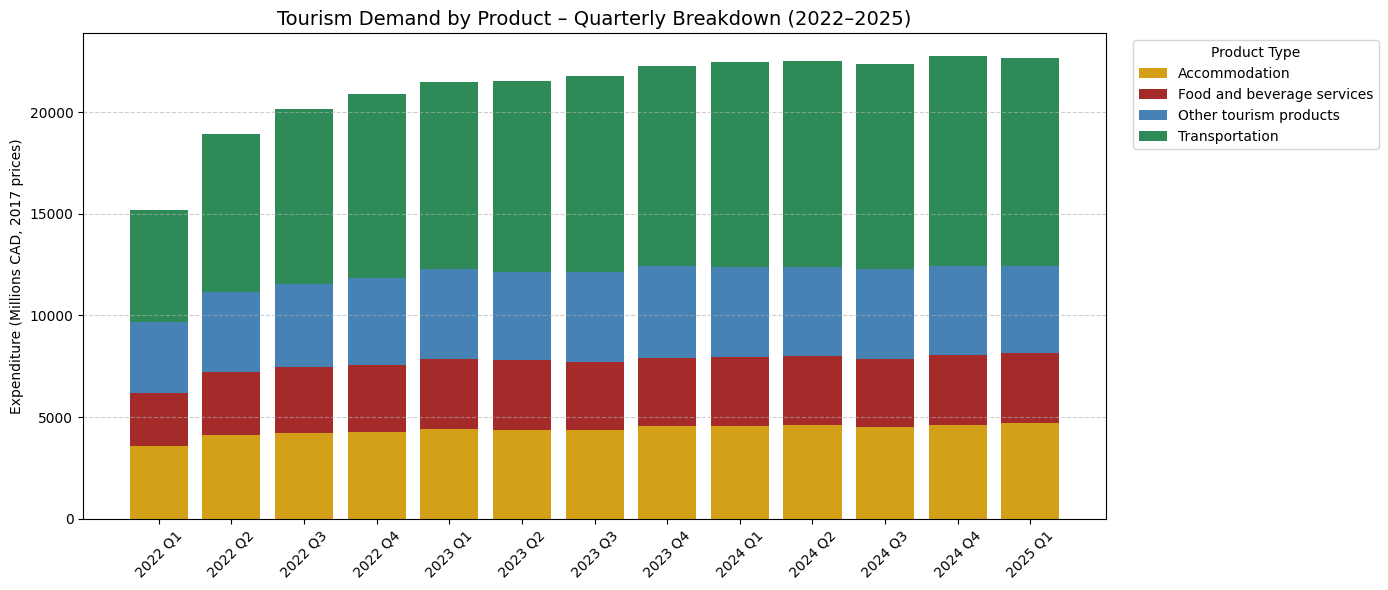

In [189]:
demand_parts = tourism_demand[
    (tourism_demand["REF_DATE"] >= "2022-01") &
    (tourism_demand["Products"].isin(["Transportation", "Accommodation", "Food and beverage services", "Other tourism products"]))
].copy()


demand_parts["Year"] = demand_parts["REF_DATE"].str[:4]
demand_parts["Quarter"] = demand_parts["REF_DATE"].str[-2:].replace({
    "01": "Q1", "04": "Q2", "07": "Q3", "10": "Q4"
})
demand_parts["Label"] = demand_parts["Year"] + " " + demand_parts["Quarter"]


demand_pivot = demand_parts.pivot_table(
    index="Label",
    columns="Products",
    values="VALUE",
    aggfunc="sum"
).fillna(0)


demand_pivot = demand_pivot.loc[sorted(demand_pivot.index, key=lambda x: (x.split()[0], x.split()[1]))]


colors = {
    'Transportation': '#2e8b57',
    'Accommodation': '#d4a017',
    'Food and beverage services': '#a52a2a',
    'Other tourism products': '#4682b4'
}

fig, ax = plt.subplots(figsize=(14, 6))

bottom = pd.Series([0]*len(demand_pivot), index=demand_pivot.index)
for column in demand_pivot.columns:
    ax.bar(demand_pivot.index, demand_pivot[column], bottom=bottom, label=column, color=colors[column])
    bottom += demand_pivot[column]

ax.set_title("Tourism Demand by Product – Quarterly Breakdown (2022–2025)", fontsize=14)
ax.set_ylabel("Expenditure (Millions CAD, 2017 prices)")
ax.set_xticks(range(len(demand_pivot.index)))
ax.set_xticklabels(demand_pivot.index, rotation=45)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
ax.legend(title="Product Type", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

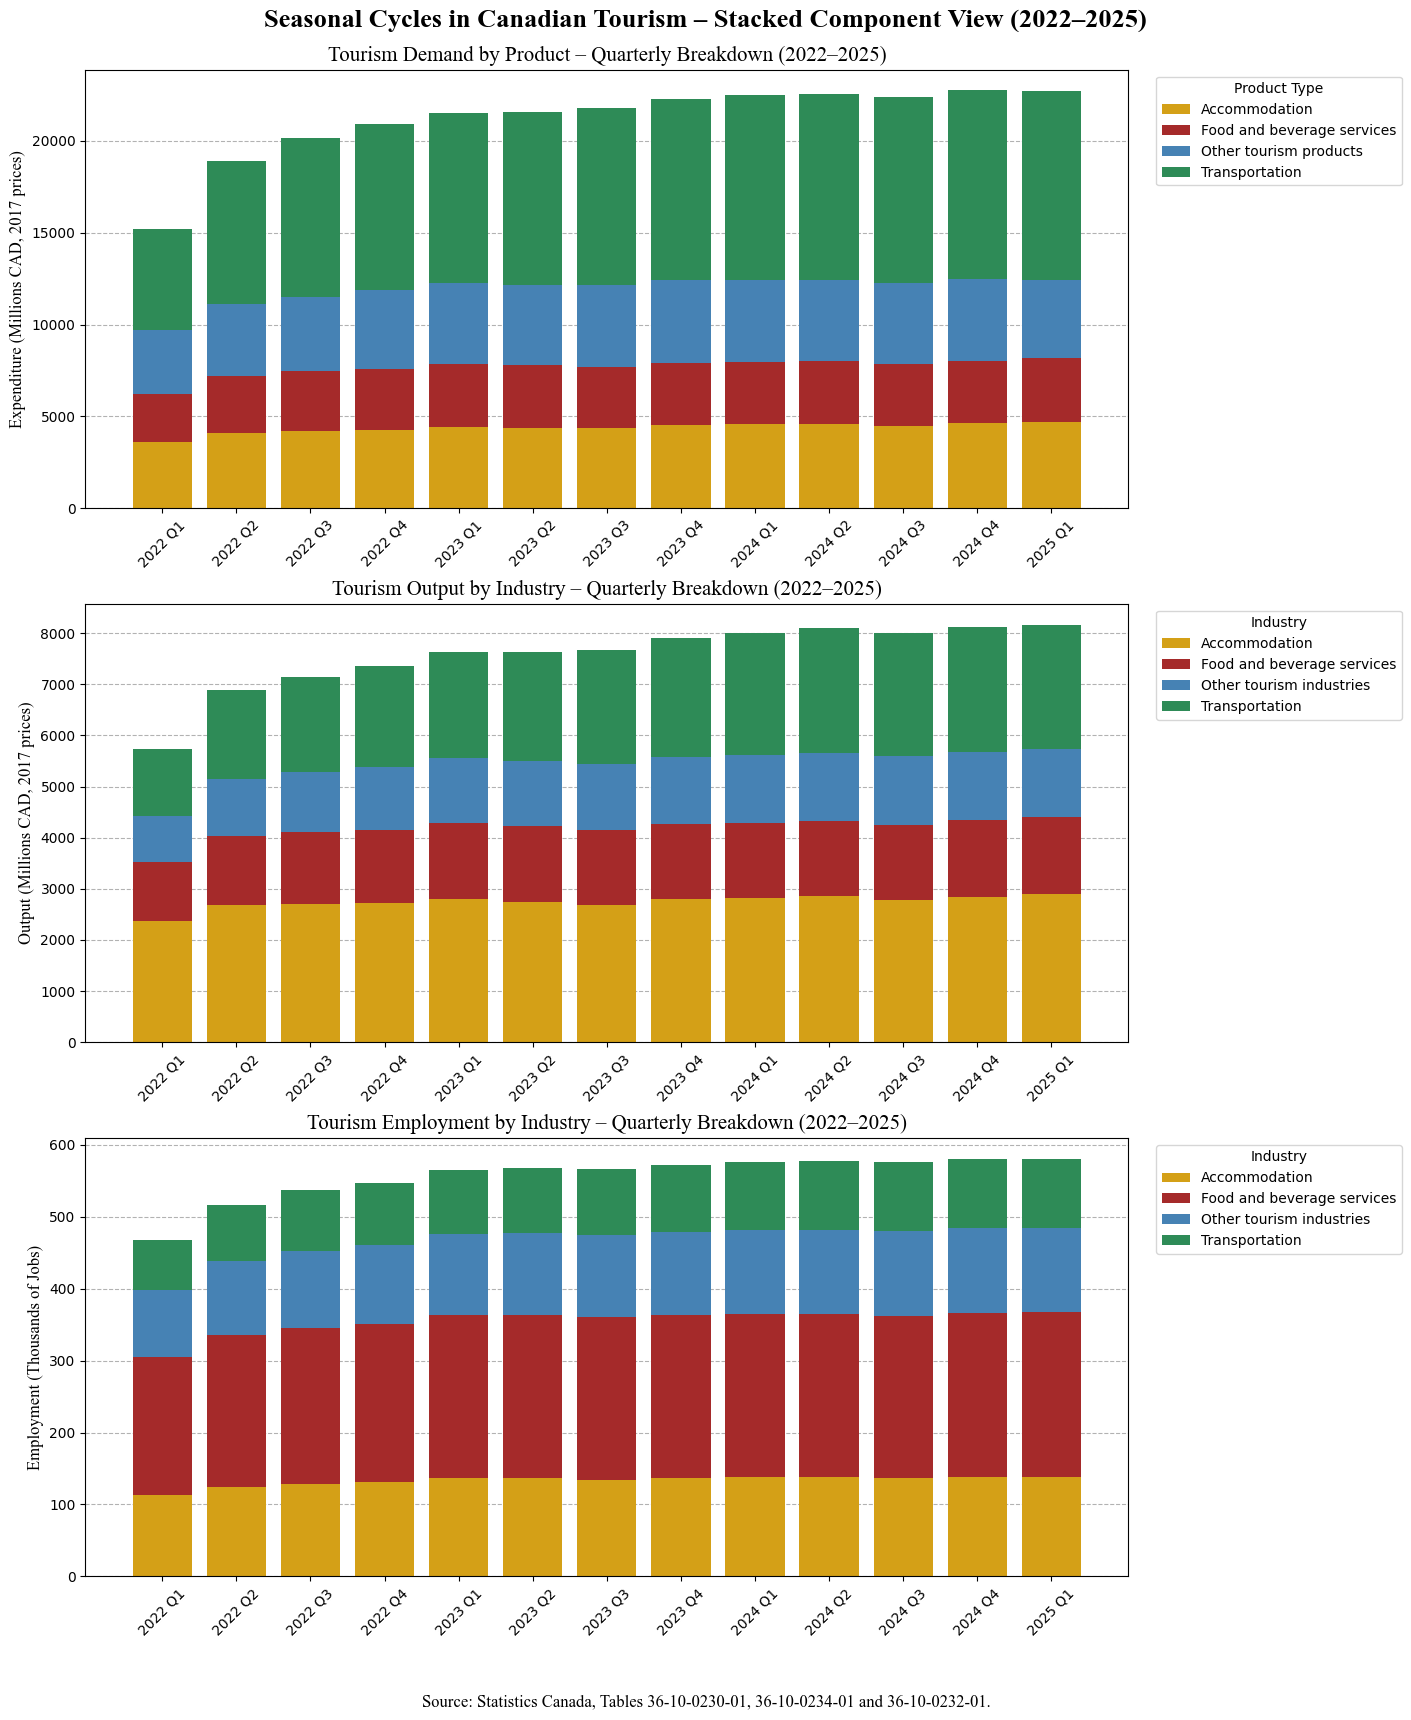

In [203]:
demand_parts = tourism_demand[
    (tourism_demand["REF_DATE"] >= "2022-01") &
    (tourism_demand["Products"].isin(["Transportation", "Accommodation", "Food and beverage services", "Other tourism products"]))
].copy()
demand_parts["Year"] = demand_parts["REF_DATE"].str[:4]
demand_parts["Quarter"] = demand_parts["REF_DATE"].str[-2:].replace({"01": "Q1", "04": "Q2", "07": "Q3", "10": "Q4"})
demand_parts["Label"] = demand_parts["Year"] + " " + demand_parts["Quarter"]
demand_pivot = demand_parts.pivot_table(index="Label", columns="Products", values="VALUE", aggfunc="sum").fillna(0)
demand_pivot = demand_pivot.loc[sorted(demand_pivot.index, key=lambda x: (x.split()[0], x.split()[1]))]


jobs_parts = tourism_jobs[
    (tourism_jobs["REF_DATE"] >= "2022-01") &
    (tourism_jobs["Industries"].isin(["Transportation", "Accommodation", "Food and beverage services", "Other tourism industries"]))
].copy()
jobs_parts["Year"] = jobs_parts["REF_DATE"].str[:4]
jobs_parts["Quarter"] = jobs_parts["REF_DATE"].str[-2:].replace({"01": "Q1", "04": "Q2", "07": "Q3", "10": "Q4"})
jobs_parts["Label"] = jobs_parts["Year"] + " " + jobs_parts["Quarter"]
jobs_pivot = jobs_parts.pivot_table(index="Label", columns="Industries", values="VALUE", aggfunc="sum").fillna(0)
jobs_pivot = jobs_pivot.loc[sorted(jobs_pivot.index, key=lambda x: (x.split()[0], x.split()[1]))]


output_parts = tourism_industry_expenditure[
    (tourism_industry_expenditure["REF_DATE"] >= "2022-01") &
    (tourism_industry_expenditure["Industries"].isin(["Transportation", "Accommodation", "Food and beverage services", "Other tourism industries"]))
].copy()
output_parts["Year"] = output_parts["REF_DATE"].str[:4]
output_parts["Quarter"] = output_parts["REF_DATE"].str[-2:].replace({"01": "Q1", "04": "Q2", "07": "Q3", "10": "Q4"})
output_parts["Label"] = output_parts["Year"] + " " + output_parts["Quarter"]
output_pivot = output_parts.pivot_table(index="Label", columns="Industries", values="VALUE", aggfunc="sum").fillna(0)
output_pivot = output_pivot.loc[sorted(output_pivot.index, key=lambda x: (x.split()[0], x.split()[1]))]


colors = {
    'Transportation': '#2e8b57',
    'Accommodation': '#d4a017',
    'Food and beverage services': '#a52a2a',
    'Other tourism industries': '#4682b4',
    'Other tourism products': '#4682b4'
}


fig, axs = plt.subplots(3, 1, figsize=(14, 16), constrained_layout=True)


bottom = pd.Series([0]*len(demand_pivot), index=demand_pivot.index)
for col in demand_pivot.columns:
    axs[0].bar(demand_pivot.index, demand_pivot[col], bottom=bottom, label=col, color=colors[col], zorder=2)
    bottom += demand_pivot[col]
axs[0].set_title("Tourism Demand by Product – Quarterly Breakdown (2022–2025)", fontname='Times New Roman', fontsize=15)
axs[0].set_ylabel("Expenditure (Millions CAD, 2017 prices)", fontname='Times New Roman', fontsize=12)
axs[0].set_xticks(range(len(demand_pivot.index)))
axs[0].set_xticklabels(demand_pivot.index, rotation=45)
axs[0].grid(True, axis='y', linestyle='--', alpha=0.3, color='k', zorder=1)
axs[0].legend(title="Product Type", bbox_to_anchor=(1.02, 1), loc='upper left')


bottom = pd.Series([0]*len(jobs_pivot), index=jobs_pivot.index)
for col in jobs_pivot.columns:
    axs[2].bar(jobs_pivot.index, jobs_pivot[col], bottom=bottom, label=col, color=colors[col], zorder=2)
    bottom += jobs_pivot[col]
axs[2].set_title("Tourism Employment by Industry – Quarterly Breakdown (2022–2025)", fontname='Times New Roman', fontsize=15)
axs[2].set_ylabel("Employment (Thousands of Jobs)", fontname='Times New Roman', fontsize=12)
axs[2].set_xticks(range(len(jobs_pivot.index)))
axs[2].set_xticklabels(jobs_pivot.index, rotation=45)
axs[2].grid(True, axis='y', linestyle='--', alpha=0.3, color='k', zorder=1)
axs[2].legend(title="Industry", bbox_to_anchor=(1.02, 1), loc='upper left')


bottom = pd.Series([0]*len(output_pivot), index=output_pivot.index)
for col in output_pivot.columns:
    axs[1].bar(output_pivot.index, output_pivot[col], bottom=bottom, label=col, color=colors[col], zorder=2)
    bottom += output_pivot[col]
axs[1].set_title("Tourism Output by Industry – Quarterly Breakdown (2022–2025)", fontname='Times New Roman', fontsize=15)
axs[1].set_ylabel("Output (Millions CAD, 2017 prices)", fontname='Times New Roman', fontsize=12)
axs[1].set_xticks(range(len(output_pivot.index)))
axs[1].set_xticklabels(output_pivot.index, rotation=45)
axs[1].grid(True, axis='y', linestyle='--', alpha=0.3, color='k', zorder=1)
axs[1].legend(title="Industry", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle("Seasonal Cycles in Canadian Tourism – Stacked Component View (2022–2025)",
             fontname='Times New Roman', fontsize=19, fontweight='bold', y=1.02)

plt.figtext(0.5, -0.04,
            'Source: Statistics Canada, Tables 36-10-0230-01, 36-10-0234-01 and 36-10-0232-01.',
            wrap=True, horizontalalignment='center', fontsize=12, fontname='Times New Roman', weight='medium')

#plt.savefig('tourism_quarterly_components_2022_2025.png', dpi=500, bbox_inches='tight')

plt.show()

## Numbers in data at 2025

In [211]:
# Load datasets (already done earlier if needed)
tourism_demand = pd.read_csv('3610023001_databaseLoadingData.csv')
tourism_jobs = pd.read_csv('3610023201_databaseLoadingData.csv')
tourism_gdp_share = pd.read_csv('3610023501_databaseLoadingData.csv')
tourism_industry_expenditure = pd.read_csv('3610023401_databaseLoadingData.csv')

print("Tourism Demand in Q1 2025 (Millions CAD):")
q1_2025_demand = tourism_demand[
    (tourism_demand["REF_DATE"] == "2025-01")
    & (tourism_demand["Indicators"] == "Tourism demand")
print(q1_2025_demand[["Products", "VALUE"]])

print("\nTourism Jobs in Q1 2025 (Thousands):")
q1_2025_jobs = tourism_jobs[
    (tourism_jobs["REF_DATE"] == "2025-01")
]
print(q1_2025_jobs[["Industries", "VALUE"]])

gdp_q1_2025 = tourism_gdp_share[tourism_gdp_share["REF_DATE"] == "2025-01"]["VALUE"].values[0]

print(f"\nTourism share of GDP in Q1 2025: {gdp_q1_2025:.2f}%")

print("\nTourism Industry Output in Q1 2025 (Millions CAD):")
q1_2025_output = tourism_industry_expenditure[
    (tourism_industry_expenditure["REF_DATE"] == "2025-01")
]
print(q1_2025_output[["Industries", "VALUE"]])

Tourism Demand in Q1 2025 (Millions CAD):
                       Products  VALUE
121              Transportation  10285
182               Accommodation   4716
243  Food and beverage services   3457
304      Other tourism products   4240

Tourism Jobs in Q1 2025 (Thousands):
                     Industries  VALUE
121              Transportation   96.0
182               Accommodation  138.8
243  Food and beverage services  228.8
304    Other tourism industries  117.2

Tourism share of GDP in Q1 2025: 1.74%

Tourism Industry Output in Q1 2025 (Millions CAD):
                     Industries  VALUE
121              Transportation   2436
182               Accommodation   2907
243  Food and beverage services   1504
304    Other tourism industries   1320
